the following data are  |  Warfarin  |  63  |  
Severity
Mild        138
Moderate     65
Severe      100
Name: Count, dtype: int64


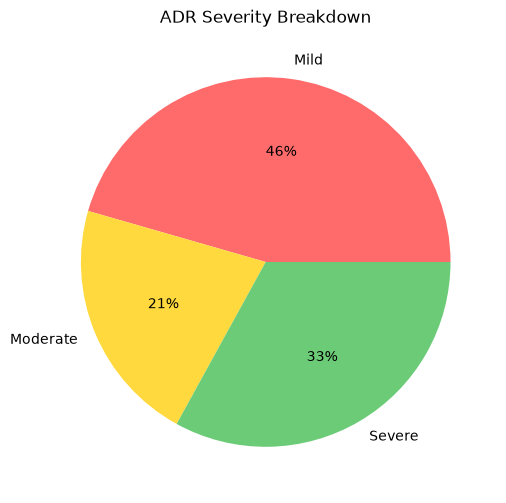

In [6]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

data = {
    "Drug": [
        "Metformin", "Metformin",
        "Warfarin", "Warfarin",
        "Aspirin", "Aspirin",
        "Insulin", "Insulin",
        "Atorvastatin", "Atorvastatin",
        "Amoxicillin", "Amoxicillin"
    ],

    "ADR_Event": [
        "Nausea", "Lactic Acidosis",
        "Bleeding", "Bruising",
        "GI Upset", "GI Bleeding",
        "Hypoglycemia", "Injection Pain",
        "Myalgia", "Headache",
        "Rash", "Diarrhea"
    ],

    "Severity": [
        "Mild", "Severe",
        "Severe", "Moderate",
        "Mild", "Severe",
        "Severe", "Mild",
        "Moderate", "Mild",
        "Moderate", "Mild"
    ],

    "Count": [
        45, 8,
        38, 25,
        30, 12,
        42, 20,
        18, 15,
        22, 28
    ]
}

df = pd.DataFrame(data)
df

drug_total_1 = df.groupby("Drug")["Count"].sum()

drug_total_1

top_count = drug_total_1.max()
top_drug = drug_total_1.idxmax()

print(f"the following data are  |  {top_drug}  |  {top_count}  |  ")


severity = df.groupby("Severity")["Count"].sum()
print(severity)


conn = sqlite3.connect("adr_data.db")
df.to_sql("adr_data", conn, if_exists="replace", index=False)

cursor = conn.cursor()
cursor.execute("select Drug, Severity, Count from adr_data where Severity = 'Severe' order by Count desc")
cursor.fetchall()


plt.figure(figsize=(6, 6))
plt.pie(severity.values,
        labels=severity.index,
        autopct="%1.0f%%",
        colors=["#ff6b6b", "#ffd93d", "#6bcb77"])
plt.title("ADR Severity Breakdown")
plt.savefig("adr_severity.png", dpi=150)
plt.show()



